# Seq2Seq машинный перевод с Attention

In [8]:
import importlib.util
import subprocess
import sys

missing = [pkg for pkg in ['datasets', 'subword_nmt'] if importlib.util.find_spec(pkg) is None]

if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'datasets', 'accelerate', 'subword-nmt'])
else:
    print("Required packages are already installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.3
    Uninstalling datasets-4.8.3:
      Successfully uninstalled datasets-4.8.3
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0


In [9]:
import sys

import numpy as np
from sklearn.model_selection import train_test_split
from tqdm.auto import trange

import torch
import torch.nn as nn
import torch.nn.functional as F

from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE

import bokeh.plotting as pl
import bokeh.models as bm
from bokeh.io import output_notebook, show

import datasets
import transformers
from huggingface_hub import hf_hub_download

import matplotlib.pyplot as plt
from IPython.display import clear_output
%matplotlib inline

if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

torch.manual_seed(42)
np.random.seed(42)
print("Using device:", device)

Using device: cpu


## Машинный перевод: Encoder-Decoder подход



![img](https://esciencegroup.files.wordpress.com/2016/03/seq2seq.jpg)



### Подготовка данных


In [10]:
from pathlib import Path
import urllib.request

data_path = Path("data.txt")
if not data_path.exists():
    urllib.request.urlretrieve(
        "https://www.dropbox.com/s/yy2zqh34dyhv07i/data.txt?dl=1",
        data_path,
    )

print(data_path.resolve())

/kaggle/working/data.txt


## Subword-токенизация

In [11]:
tokenizer = WordPunctTokenizer()

def tokenize(x):
    return ' '.join(tokenizer.tokenize(x.lower()))

if not Path("train.bpe.en").exists() or not Path("train.bpe.ru").exists():
    # split and tokenize the data
    with open('train.en', 'w') as f_src,  open('train.ru', 'w') as f_dst:
        for line in open('data.txt'):
            src_line, dst_line = line.strip().split('\t')
            f_src.write(tokenize(src_line) + '\n')
            f_dst.write(tokenize(dst_line) + '\n')

    # build and apply bpe vocs
    bpe = {}
    for lang in ['en', 'ru']:
        learn_bpe(open('./train.' + lang), open('bpe_rules.' + lang, 'w'), num_symbols=8000)
        bpe[lang] = BPE(open('./bpe_rules.' + lang))

        with open('train.bpe.' + lang, 'w') as f_out:
            for line in open('train.' + lang):
                f_out.write(bpe[lang].process_line(line.strip()) + '\n')

100%|██████████| 8000/8000 [00:13<00:00, 611.62it/s] 


### Построение словарей

In [12]:
class Vocab:
    def __init__(self, tokens, bos="_BOS_", eos="_EOS_", unk='_UNK_'):
        """
        A special class that converts lines of tokens into matrices and backwards
        """
        assert all(tok in tokens for tok in (bos, eos, unk))
        self.tokens = tokens
        self.token_to_ix = {t:i for i, t in enumerate(tokens)}
        self.bos, self.eos, self.unk = bos, eos, unk
        self.bos_ix = self.token_to_ix[bos]
        self.eos_ix = self.token_to_ix[eos]
        self.unk_ix = self.token_to_ix[unk]

    def __len__(self):
        return len(self.tokens)

    @staticmethod
    def from_lines(lines, bos="_BOS_", eos="_EOS_", unk='_UNK_'):
        flat_lines = '\n'.join(list(lines)).split()
        tokens = sorted(set(flat_lines))
        tokens = [t for t in tokens if t not in (bos, eos, unk) and len(t)]
        tokens = [bos, eos, unk] + tokens
        return Vocab(tokens, bos, eos, unk)

    def tokenize(self, string):
        """converts string to a list of tokens"""
        tokens = [tok if tok in self.token_to_ix else self.unk
                  for tok in string.split()]
        return [self.bos] + tokens + [self.eos]

    def to_matrix(self, lines, dtype=torch.int64, max_len=None):
        """
        convert variable length token sequences into  fixed size matrix
        example usage:
        >>>print(to_matrix(words[:3],source_to_ix))
        [[15 22 21 28 27 13 -1 -1 -1 -1 -1]
         [30 21 15 15 21 14 28 27 13 -1 -1]
         [25 37 31 34 21 20 37 21 28 19 13]]
        """
        lines = list(map(self.tokenize, lines))
        max_len = max_len or max(map(len, lines))

        matrix = torch.full((len(lines), max_len), self.eos_ix, dtype=dtype)
        for i, seq in enumerate(lines):
            row_ix = list(map(self.token_to_ix.get, seq))[:max_len]
            matrix[i, :len(row_ix)] = torch.as_tensor(row_ix)

        return matrix

    def to_lines(self, matrix, crop=True):
        """
        Convert matrix of token ids into strings
        :param matrix: matrix of tokens of int32, shape=[batch,time]
        :param crop: if True, crops BOS and EOS from line
        :return:
        """
        lines = []
        for line_ix in map(list,matrix):
            if crop:
                if line_ix[0] == self.bos_ix:
                    line_ix = line_ix[1:]
                if self.eos_ix in line_ix:
                    line_ix = line_ix[:line_ix.index(self.eos_ix)]
            line = ' '.join(self.tokens[i] for i in line_ix)
            lines.append(line)
        return lines

    def compute_mask(self, input_ix):
        """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
        return F.pad(torch.cumsum(input_ix == self.eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)

In [13]:
data_inp = np.array([line for line in open('./train.bpe.ru').read().split('\n') if line])
data_out = np.array([line for line in open('./train.bpe.en').read().split('\n') if line])

train_inp, dev_inp, train_out, dev_out = train_test_split(data_inp, data_out, test_size=3000,
                                                          random_state=42)
for i in range(3):
    print('inp:', train_inp[i])
    print('out:', train_out[i], end='\n\n')

inp: на территории обустроена бесплатная частная парковка .
out: free private parking is available on site .

inp: кроме того , в 5 минутах ходьбы работают многочисленные бары и рестораны .
out: guests can find many bars and restaurants within a 5 - minute walk .

inp: отель san mi@@ gu@@ el расположен в центре мор@@ ели@@ и , в 750 метрах от главной площади города и кафедрального собора .
out: hotel san miguel is located in central more@@ lia , 750 metres from the city ’ s main square and cathedral .



In [14]:
inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

In [15]:
batch_lines = sorted(train_inp, key=len)[5:10]
batch_ids = inp_voc.to_matrix(batch_lines)
batch_lines_restored = inp_voc.to_lines(batch_ids)

print("lines")
print(batch_lines)

print("\nwords to ids (0 = bos, 1 = eos):")
print(batch_ids)

print("\nback to words")
print(batch_lines_restored)

lines
[np.str_('до афин — 20 км .'), np.str_('работает боулинг .'), np.str_('оборудован балкон .'), np.str_('подключен wi - fi .'), np.str_('в номерах отеля ft .')]

words to ids (0 = bos, 1 = eos):
tensor([[   0, 2922, 1834, 8036,   59, 3800,   29,    1],
        [   0, 6030, 2083,   29,    1,    1,    1,    1],
        [   0, 4927, 1870,   29,    1,    1,    1,    1],
        [   0, 5549, 1453,   27,  592,   29,    1,    1],
        [   0, 2140, 4852, 5199,  612,   29,    1,    1]])

back to words
['до афин — 20 км .', 'работает боулинг .', 'оборудован балкон .', 'подключен wi - fi .', 'в номерах отеля ft .']


Посмотрим на распределения длин исходных текстов и переводов, чтобы оценить объем задачи

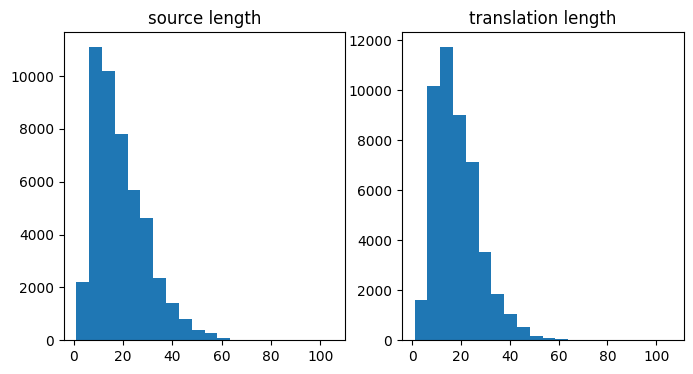

In [28]:
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(map(len, map(str.split, train_inp))), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(map(len, map(str.split, train_out))), bins=20);

### Базовая модель


Простая модель Encoder-Decoder: однослойный GRU-кодировщик/декодировщик без механизма внимания или каких-либо дополнительных функций

Реализация `decode_step`

In [16]:
class BasicModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        """
        A simple encoder-decoder seq2seq model
        """
        super().__init__() # initialize base class to track sub-layers, parameters, etc.

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        """ Apply model in training mode """
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)

    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :returns: initial decoder state tensors, one or many
        """
        inp_emb = self.emb_inp(inp)
        batch_size = inp.shape[0]

        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        # enc_seq: [batch, time, hid_size], last_state: [batch, hid_size]

        # note: last_state is not _actually_ last because of padding, let's find the real last_state
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors, same as returned by encode(...)
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, len(out_voc)]
        """
        prev_gru0_state = prev_state[0]

        prev_emb = self.emb_out(prev_tokens)
        new_dec_state = [self.dec0(prev_emb, prev_gru0_state)]
        output_logits = self.logits(new_dec_state[0])

        return new_dec_state, output_logits

    def decode(self, initial_state, out_tokens, **flags):
        """ Iterate over reference tokens (out_tokens) with decode_step """
        batch_size = out_tokens.shape[0]
        state = initial_state

        # initial logits: always predict BOS
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, **flags):
        """ Generate translations from model (greedy version) """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, **kwargs):
        model_device = next(self.parameters()).device
        inp = self.inp_voc.to_matrix(inp_lines).to(model_device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)

        return self.out_voc.to_lines(out_ids.cpu().numpy()), states

Проверка корректности

In [17]:
model = BasicModel(inp_voc, out_voc).to(device)

dummy_inp_tokens = inp_voc.to_matrix(sorted(train_inp, key=len)[5:10]).to(device)
dummy_out_tokens = out_voc.to_matrix(sorted(train_out, key=len)[5:10]).to(device)

h0 = model.encode(dummy_inp_tokens)
h1, logits1 = model.decode_step(h0, torch.arange(len(dummy_inp_tokens), device=device))

assert isinstance(h1, list) and len(h1) == len(h0)
assert h1[0].shape == h0[0].shape and not torch.allclose(h1[0], h0[0])
assert logits1.shape == (len(dummy_inp_tokens), len(out_voc))

logits_seq = model.decode(h0, dummy_out_tokens)
assert logits_seq.shape == (dummy_out_tokens.shape[0], dummy_out_tokens.shape[1], len(out_voc))

# full forward
logits_seq2 = model(dummy_inp_tokens, dummy_out_tokens)
assert logits_seq2.shape == logits_seq.shape

In [18]:
dummy_translations, dummy_states = model.translate_lines(train_inp[:3], max_len=25)

print("Translations without training:")
print('\n'.join([line for line in dummy_translations]))

Translations without training:
ristorante ire suburbs meri coral computers commun@@ ck@@ bad@@ activities ère coral within within soothing soothing cardiff square ń sour@@ schloss additional alam@@ municipal municipal
bok solarium elia kan@@ karlovy auth@@ win@@ beck nom wines gand@@ il@@ tains iano sto class organized logical chambres gest paid 16@@ years nab@@ nab@@
ristorante ire suburbs meri coral computers commun@@ ck@@ bad@@ activities ère coral within within soothing soothing cardiff square ń sour@@ schloss additional alam@@ municipal municipal




---



### Функция потерь



Целевая функция:

$$ L = {\frac1{|D|}} \sum_{X, Y \in D} \sum_{y_t \in Y} - \log p(y_t \mid y_1, \dots, y_{t-1}, X, \theta) $$

где $|D|$ — это __общая длина всех последовательностей__, включая BOS и первый EOS, но исключая PAD.

In [19]:
def compute_loss(model, inp, out, **flags):
    """
    Compute loss (float32 scalar) as in the formula above
    :param inp: input tokens matrix, int32[batch, time]
    :param out: reference tokens matrix, int32[batch, time]

    In order to pass the tests, your function should
    * include loss at first EOS but not the subsequent ones
    * divide sum of losses by a sum of input lengths (use voc.compute_mask)
    """
    mask = model.out_voc.compute_mask(out) # [batch_size, out_len]
    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32)

    # outputs of the model, [batch_size, out_len, num_tokens]
    logits_seq = model(inp, out)

    # log-probabilities of all tokens at all steps, [batch_size, out_len, num_tokens]
    logprobs_seq = F.log_softmax(logits_seq, dim=-1)

    # log-probabilities of correct outputs, [batch_size, out_len]
    logp_out = (logprobs_seq * targets_1hot).sum(dim=-1)
    # ^-- this will select the probability of the actual next token.
    # Note: you can compute loss more efficiently using using F.cross_entropy

    # average cross-entropy over tokens where mask == True
    return -(logp_out * mask).sum() / mask.to(torch.float32).sum() # average loss, scalar

Проверка корректности

In [20]:
dummy_loss = compute_loss(model, dummy_inp_tokens, dummy_out_tokens)
print("Loss:", dummy_loss)

assert np.allclose(dummy_loss.item(), 7.5, rtol=0.1, atol=0.1), "We're sorry for your loss"

# test autograd
dummy_loss.backward()
for name, param in model.named_parameters():
    assert param.grad is not None and abs(param.grad.max()) != 0, f"Param {name} received no gradients"

print('Nice!')

Loss: tensor(7.5357, grad_fn=<DivBackward0>)
Nice!




---



## Оценка BLEU

Для сравнения моделей рассчитываем BLEU на validation set.

In [21]:
from nltk.translate.bleu_score import corpus_bleu

def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', **flags):
    """
    Estimates corpora-level BLEU score of model's translations given inp and reference out
    Note: if you're serious about reporting your results, use https://pypi.org/project/sacrebleu
    """
    with torch.no_grad():
        translations, _ = model.translate_lines(inp_lines, **flags)
        translations = [line.replace(bpe_sep, '') for line in translations]
        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu(
            [[ref.split()] for ref in actual],
            [trans.split() for trans in translations],
            smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
            ) * 100

In [22]:
compute_bleu(model, dev_inp[:100], dev_out[:100], max_len=50)


0.052148077168165



---



### Обучение


In [26]:
metrics = {'train_loss': [], 'dev_bleu': [] }

model = BasicModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32
train_max_len = 50
dev_subset = 100

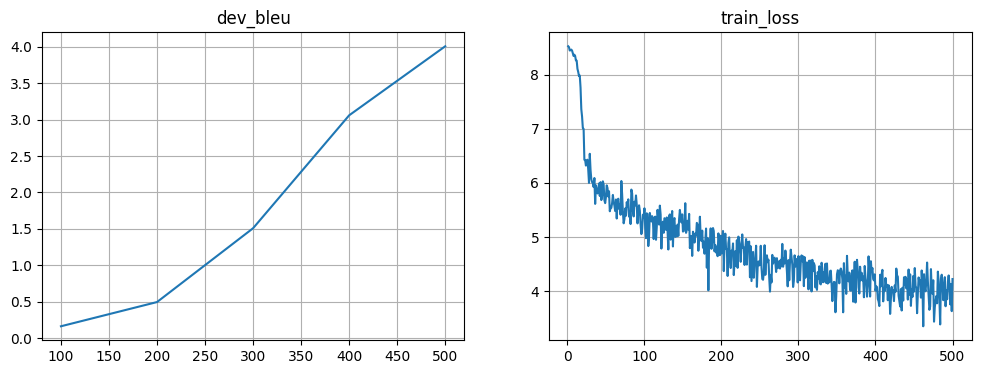

Mean loss=3.994


In [37]:
for _ in trange(500):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix], max_len=train_max_len).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix], max_len=train_max_len).to(device)

    opt.zero_grad()
    loss_t = compute_loss(model, batch_inp, batch_out)
    loss_t.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 100 == 0:
        metrics['dev_bleu'].append(
            (step, compute_bleu(model, dev_inp[:dev_subset], dev_out[:dev_subset], max_len=train_max_len))
        )

        clear_output(True)
        plt.figure(figsize=(12,4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)

In [38]:
if metrics['dev_bleu']:
    recent_bleu = [score for _, score in metrics['dev_bleu'][-min(5, len(metrics['dev_bleu'])):]]
    print(f"Final validation BLEU on {dev_subset} examples: {np.mean(recent_bleu):.2f}")

Final validation BLEU on 100 examples: 1.85


In [39]:
for inp_line, trans_line in zip(dev_inp[::500], model.translate_lines(dev_inp[::500], max_len=train_max_len)[0]):
    print(inp_line)
    print(trans_line)


в распоряжении гостей общая кухня и общая гостиная .
the rooms have a seating area and a seating area .
кроме того , предоставляется прокат велосипедов , услуги трансфера и бесплатная парковка .
free wifi is available in the property .
расстояние до города ки@@ сси@@ м@@ ми составляет 26 км .
the nearest airport is a 10 - minute drive away .
апартаменты в пент@@ хаусе с общим открытым бассейном , садом , кондиционером и террасой для загара расположены в 5 минутах ходьбы от пляжа на курорте ка@@ бо - рой .
the hotel is located in the property .
апартаменты mo@@ s@@ co@@ w point - loft red square находятся в москве , в 200 метрах от большого театра .
the property is a 10 - minute walk from the property .
в вашем распоряжении собственная ванная комната с душем и полотенцами .
the rooms have a seating area and a seating area .




---



## Additive Attention

Добавляем attention-слой, который вычисляет веса по состояниям encoder и формирует контекстный вектор для decoder.

Для каждого состояния encoder вычисляется attention score, затем веса нормализуются через softmax и используются для взвешенной суммы encoder states.

In [27]:
class AttentionLayer(nn.Module):
    def __init__(self, name, enc_size, dec_size, hid_size, activ=torch.tanh):
        """ A layer that computes additive attention response and weights """
        super().__init__()
        self.name = name
        self.enc_size = enc_size # num units in encoder state
        self.dec_size = dec_size # num units in decoder state
        self.hid_size = hid_size # attention layer hidden units
        self.activ = activ       # attention layer hidden nonlinearity

        self.enc_proj = nn.Linear(enc_size, hid_size)
        self.dec_proj = nn.Linear(dec_size, hid_size)
        self.score = nn.Linear(hid_size, 1)

    def forward(self, enc, dec, inp_mask):
        """
        Computes attention response and weights
        :param enc: encoder activation sequence, float32[batch_size, ninp, enc_size]
        :param dec: single decoder state used as "query", float32[batch_size, dec_size]
        :param inp_mask: mask on enc activatons (0 after first eos), float32 [batch_size, ninp]
        :returns: attn[batch_size, enc_size], probs[batch_size, ninp]
            - attn - attention response vector (weighted sum of enc)
            - probs - attention weights after softmax
        """

        # Compute logits
        logits = self.score(self.activ(self.enc_proj(enc) + self.dec_proj(dec)[:, None, :])).squeeze(-1)

        # Apply mask - if mask is 0, logits should be -inf or -1e9
        # You may need torch.where
        logits = torch.where(inp_mask.bool(), logits, torch.full_like(logits, -1e9))

        # Compute attention probabilities (softmax)
        probs = F.softmax(logits, dim=-1)

        # Compute attention response using enc and probs
        attn = torch.sum(enc * probs.unsqueeze(-1), dim=1)

        return attn, probs



---



## Seq2Seq модель с Attention

Расширяем базовую модель: decoder использует не только hidden state, но и контекстный вектор attention на каждом шаге генерации.




![img](https://i.imgur.com/6fKHlHb.png)

In [30]:
class AttentiveModel(BasicModel):
    def __init__(self, name, inp_voc, out_voc,
                 emb_size=64, hid_size=128, attn_size=128):
        """ Translation model that uses attention. See instructions above. """
        nn.Module.__init__(self)  # initialize base class to track sub-layers, trainable variables, etc.
        self.name = name
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.attn = AttentionLayer(name + "_attn", hid_size, hid_size, attn_size)
        self.dec0 = nn.GRUCell(emb_size + hid_size, hid_size)
        self.logits = nn.Linear(hid_size + hid_size, len(out_voc))

    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :return: a list of initial decoder state tensors
        """

        # encode input sequence, create initial decoder states
        inp_emb = self.emb_inp(inp)
        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)

        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        dec_start = self.dec_start(last_state)
        inp_mask = self.inp_voc.compute_mask(inp)

        # apply attention layer from initial decoder hidden state
        first_attn, first_attn_probas = self.attn(enc_seq, dec_start, inp_mask)

        # Build first state: include
        # * initial states for decoder recurrent layers
        # * encoder sequence and encoder attn mask (for attention)
        # * make sure that last state item is attention probabilities tensor
        first_state = [dec_start, enc_seq, inp_mask, first_attn, first_attn_probas]
        return first_state

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, n_tokens]
        """

        prev_dec_state, enc_seq, inp_mask, prev_attn, prev_attn_probs = prev_state
        prev_emb = self.emb_out(prev_tokens)
        gru_input = torch.cat([prev_emb, prev_attn], dim=-1)

        new_dec_state = self.dec0(gru_input, prev_dec_state)
        new_attn, attn_probs = self.attn(enc_seq, new_dec_state, inp_mask)
        output_logits = self.logits(torch.cat([new_dec_state, new_attn], dim=-1))

        return [new_dec_state, enc_seq, inp_mask, new_attn, attn_probs], output_logits


---



## Обучение модели с Attention


Обучаем attention-based модель и сравниваем её качество с базовой архитектурой.

In [42]:
metrics = {'train_loss': [], 'dev_bleu': []}

model = AttentiveModel('attentive', inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32
train_max_len = 50
dev_subset = 200


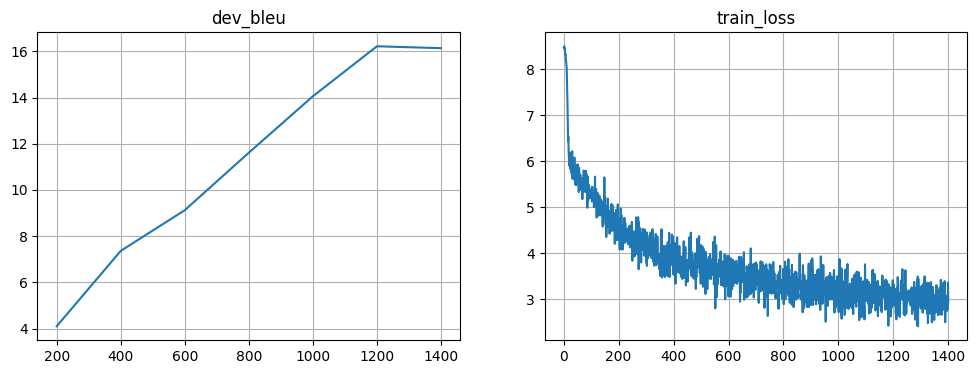

Step 1400: loss=2.958, bleu=16.14


In [43]:
for _ in trange(1400):
    step = len(metrics['train_loss']) + 1
    batch_ix = np.random.randint(len(train_inp), size=batch_size)
    batch_inp = inp_voc.to_matrix(train_inp[batch_ix], max_len=train_max_len).to(device)
    batch_out = out_voc.to_matrix(train_out[batch_ix], max_len=train_max_len).to(device)

    opt.zero_grad()
    loss_t = compute_loss(model, batch_inp, batch_out)
    loss_t.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()

    metrics['train_loss'].append((step, loss_t.item()))

    if step % 200 == 0:
        bleu_t = compute_bleu(model, dev_inp[:dev_subset], dev_out[:dev_subset], max_len=train_max_len)
        metrics['dev_bleu'].append((step, bleu_t))

        clear_output(True)
        plt.figure(figsize=(12, 4))
        for i, (name, history) in enumerate(sorted(metrics.items())):
            plt.subplot(1, len(metrics), i + 1)
            plt.title(name)
            plt.plot(*zip(*history))
            plt.grid()
        plt.show()
        print(f"Step {step}: loss={np.mean(metrics['train_loss'][-10:], axis=0)[1]:.3f}, bleu={bleu_t:.2f}", flush=True)


In [44]:
final_bleu = compute_bleu(model, dev_inp[:500], dev_out[:500], max_len=train_max_len)
print(f"Final BLEU on 500 validation examples: {final_bleu:.2f}")


Final BLEU on 500 validation examples: 17.09




---



## Визуализация attention maps



Строим attention-карты для отдельных примеров перевода, чтобы посмотреть, какие части исходного предложения использовались при генерации каждого токена.

In [31]:
output_notebook()

def draw_attention(inp_line, translation, probs):
    """ An intentionally ambiguous function to visualize attention weights """
    inp_tokens = inp_voc.tokenize(inp_line)
    trans_tokens = out_voc.tokenize(translation)
    probs = probs[:len(trans_tokens), :len(inp_tokens)]

    fig = pl.figure(x_range=(0, len(inp_tokens)), y_range=(0, len(trans_tokens)),
                    x_axis_type=None, y_axis_type=None, tools=[])
    fig.image([probs[::-1]], 0, 0, len(inp_tokens), len(trans_tokens))

    fig.add_layout(bm.LinearAxis(axis_label='source tokens'), 'above')
    fig.xaxis.ticker = np.arange(len(inp_tokens)) + 0.5
    fig.xaxis.major_label_overrides = dict(zip(np.arange(len(inp_tokens)) + 0.5, inp_tokens))
    fig.xaxis.major_label_orientation = 45

    fig.add_layout(bm.LinearAxis(axis_label='translation tokens'), 'left')
    fig.yaxis.ticker = np.arange(len(trans_tokens)) + 0.5
    fig.yaxis.major_label_overrides = dict(zip(np.arange(len(trans_tokens)) + 0.5, trans_tokens[::-1]))

    show(fig)

Loading BokehJS ...

In [32]:
inp = dev_inp[::500]

trans, states = model.translate_lines(inp, max_len=train_max_len)

# select attention probs from model state (you may need to change this for your custom model)
# attention_probs below must have shape [batch_size, translation_length, input_length], extracted from states
# e.g. if attention probs are at the end of each state, use np.stack([state[-1] for state in states], axis=1)
attention_probs = np.stack([state[-1].detach().cpu().numpy() for state in states], axis=1)

In [47]:
for i in range(5):
    draw_attention(inp[i], trans[i], attention_probs[i])

Выглядит хорошо, да? Не забудьте сохранить изображения!

## Эксперименты

Проверяем, как на качество перевода влияют размер модели, bidirectional encoder и разные стратегии декодирования.


In [40]:
from pathlib import Path
import copy

def prepare_strict_bpe_dataset(
    data_path='data.txt',
    prefix='strict',
    test_size=3000,
    random_state=42,
    num_symbols=8000,
):
    data_path = Path(data_path)
    needed = [
        Path(f'{prefix}_train.bpe.ru'),
        Path(f'{prefix}_train.bpe.en'),
        Path(f'{prefix}_dev.bpe.ru'),
        Path(f'{prefix}_dev.bpe.en'),
        Path(f'{prefix}_bpe_rules.ru'),
        Path(f'{prefix}_bpe_rules.en'),
    ]

    if not all(path.exists() for path in needed):
        raw_en, raw_ru = [], []
        for line in open(data_path):
            src_line, dst_line = line.strip().split('\t')
            raw_en.append(tokenize(src_line))
            raw_ru.append(tokenize(dst_line))

        raw_en = np.array(raw_en)
        raw_ru = np.array(raw_ru)

        train_en, dev_en, train_ru, dev_ru = train_test_split(
            raw_en,
            raw_ru,
            test_size=test_size,
            random_state=random_state,
        )

        for split_name, en_lines, ru_lines in [
            ('train', train_en, train_ru),
            ('dev', dev_en, dev_ru),
        ]:
            with open(f'{prefix}_{split_name}.en', 'w') as f_en:
                f_en.write('\n'.join(en_lines) + '\n')
            with open(f'{prefix}_{split_name}.ru', 'w') as f_ru:
                f_ru.write('\n'.join(ru_lines) + '\n')

        strict_bpe = {}
        for lang in ['en', 'ru']:
            with open(f'{prefix}_train.{lang}') as src, open(f'{prefix}_bpe_rules.{lang}', 'w') as dst:
                learn_bpe(src, dst, num_symbols=num_symbols)

            strict_bpe[lang] = BPE(open(f'{prefix}_bpe_rules.{lang}'))

            for split_name in ['train', 'dev']:
                with open(f'{prefix}_{split_name}.bpe.{lang}', 'w') as f_out:
                    for line in open(f'{prefix}_{split_name}.{lang}'):
                        f_out.write(strict_bpe[lang].process_line(line.strip()) + '\n')

    strict_train_inp = np.array([line for line in open(f'{prefix}_train.bpe.ru').read().split('\n') if line])
    strict_train_out = np.array([line for line in open(f'{prefix}_train.bpe.en').read().split('\n') if line])
    strict_dev_inp = np.array([line for line in open(f'{prefix}_dev.bpe.ru').read().split('\n') if line])
    strict_dev_out = np.array([line for line in open(f'{prefix}_dev.bpe.en').read().split('\n') if line])

    strict_inp_voc = Vocab.from_lines(strict_train_inp)
    strict_out_voc = Vocab.from_lines(strict_train_out)

    return {
        'train_inp': strict_train_inp,
        'train_out': strict_train_out,
        'dev_inp': strict_dev_inp,
        'dev_out': strict_dev_out,
        'inp_voc': strict_inp_voc,
        'out_voc': strict_out_voc,
    }

In [41]:
strict_data = prepare_strict_bpe_dataset()

strict_train_inp = strict_data['train_inp']
strict_train_out = strict_data['train_out']
strict_dev_inp = strict_data['dev_inp']
strict_dev_out = strict_data['dev_out']
strict_inp_voc = strict_data['inp_voc']
strict_out_voc = strict_data['out_voc']

print('strict train size:', len(strict_train_inp))
print('strict dev size:', len(strict_dev_inp))
print('strict input vocab:', len(strict_inp_voc))
print('strict output vocab:', len(strict_out_voc))

100%|██████████| 8000/8000 [00:11<00:00, 669.02it/s] 


strict train size: 47000
strict dev size: 3000
strict input vocab: 8037
strict output vocab: 7809


In [42]:
def _maybe_subset(lines, subset):
    return lines if subset is None else lines[:subset]


def train_translation_experiment(
    model,
    train_inp_lines,
    train_out_lines,
    dev_inp_lines,
    dev_out_lines,
    inp_voc,
    out_voc,
    *,
    steps=1000,
    batch_size=32,
    train_max_len=50,
    lr=1e-3,
    eval_every=200,
    dev_subset=None,
    final_subset=None,
    grad_clip=1.0,
    show_plots=True,
):
    metrics = {'train_loss': [], 'dev_bleu': []}
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_bleu = -float('inf')
    best_state = copy.deepcopy(model.state_dict())
    eval_inp = _maybe_subset(dev_inp_lines, dev_subset)
    eval_out = _maybe_subset(dev_out_lines, dev_subset)
    final_inp = _maybe_subset(dev_inp_lines, final_subset)
    final_out = _maybe_subset(dev_out_lines, final_subset)

    for _ in trange(steps):
        step = len(metrics['train_loss']) + 1
        batch_ix = np.random.randint(len(train_inp_lines), size=batch_size)
        batch_inp = inp_voc.to_matrix(train_inp_lines[batch_ix], max_len=train_max_len).to(device)
        batch_out = out_voc.to_matrix(train_out_lines[batch_ix], max_len=train_max_len).to(device)

        opt.zero_grad()
        loss_t = compute_loss(model, batch_inp, batch_out)
        loss_t.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()

        metrics['train_loss'].append((step, loss_t.item()))

        if step % eval_every == 0:
            bleu_t = compute_bleu(
                model,
                eval_inp,
                eval_out,
                max_len=train_max_len,
            )
            metrics['dev_bleu'].append((step, bleu_t))

            if bleu_t > best_bleu:
                best_bleu = bleu_t
                best_state = copy.deepcopy(model.state_dict())

            if show_plots:
                clear_output(True)
                plt.figure(figsize=(12, 4))
                for i, (name, history) in enumerate(sorted(metrics.items())):
                    plt.subplot(1, len(metrics), i + 1)
                    plt.title(name)
                    plt.plot(*zip(*history))
                    plt.grid()
                plt.show()
                print(
                    f"Step {step}: loss={np.mean(metrics['train_loss'][-10:], axis=0)[1]:.3f}, "
                    f"bleu={bleu_t:.2f}, best_bleu={best_bleu:.2f}",
                    flush=True,
                )

    model.load_state_dict(best_state)
    final_bleu = compute_bleu(
        model,
        final_inp,
        final_out,
        max_len=train_max_len,
    )

    return {
        'model': model,
        'metrics': metrics,
        'best_bleu': best_bleu,
        'final_bleu': final_bleu,
        'train_max_len': train_max_len,
    }


def visualize_experiment_attention(
    result,
    inp_lines,
    inp_voc_for_plot,
    out_voc_for_plot,
    *,
    title='experiment',
    n_examples=5,
    save_n=3,
    save_dir='attention_maps_experiments',
):
    old_inp_voc = globals().get('inp_voc')
    old_out_voc = globals().get('out_voc')
    globals()['inp_voc'] = inp_voc_for_plot
    globals()['out_voc'] = out_voc_for_plot

    try:
        selected_inp = inp_lines[:max(n_examples, save_n)]
        trans, states = result['model'].translate_lines(selected_inp, max_len=result['train_max_len'])
        attention_probs = np.stack([state[-1].detach().cpu().numpy() for state in states], axis=1)

        print(f'Attention maps for {title}')
        for i in range(n_examples):
            draw_attention(selected_inp[i], trans[i], attention_probs[i])

        save_dir = Path(save_dir) / title
        save_dir.mkdir(parents=True, exist_ok=True)
        for i in range(save_n):
            inp_tokens = inp_voc_for_plot.tokenize(selected_inp[i])
            trans_tokens = out_voc_for_plot.tokenize(trans[i])
            probs = attention_probs[i][:len(trans_tokens), :len(inp_tokens)]

            from matplotlib.figure import Figure
            from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas

            fig = Figure(figsize=(max(8, len(inp_tokens) * 0.45), max(4, len(trans_tokens) * 0.45)))
            FigureCanvas(fig)
            ax = fig.add_subplot(111)
            im = ax.imshow(probs, aspect='auto', cmap='viridis')
            ax.set_xticks(range(len(inp_tokens)))
            ax.set_xticklabels(inp_tokens, rotation=45, ha='right')
            ax.set_yticks(range(len(trans_tokens)))
            ax.set_yticklabels(trans_tokens)
            fig.colorbar(im, ax=ax)
            fig.tight_layout()

            out_path = save_dir / f'{title}_attention_map_{i + 1}.png'
            fig.savefig(out_path, dpi=200, bbox_inches='tight')
            print(out_path)

        return trans, attention_probs
    finally:
        if old_inp_voc is not None:
            globals()['inp_voc'] = old_inp_voc
        if old_out_voc is not None:
            globals()['out_voc'] = old_out_voc


def summarize_experiments(results_dict):
    print('Experiment summary:')
    for name, result in results_dict.items():
        print(f'{name:>24}: best_dev_bleu={result["best_bleu"]:.2f}, final_bleu={result["final_bleu"]:.2f}')

    plt.figure(figsize=(10, 4))
    names = list(results_dict.keys())
    values = [results_dict[name]['final_bleu'] for name in names]
    plt.bar(names, values)
    plt.ylabel('BLEU on the full validation set')
    plt.xticks(rotation=20, ha='right')
    plt.grid(axis='y')
    plt.show()

In [36]:
class BiAttentiveModel(BasicModel):
    def __init__(self, name, inp_voc, out_voc,
                 emb_size=96, hid_size=128, attn_size=192):
        nn.Module.__init__(self)
        self.name = name
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size
        self.enc_size = 2 * hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True, bidirectional=True)

        self.dec_start = nn.Linear(self.enc_size, hid_size)
        self.attn = AttentionLayer(name + "_attn", self.enc_size, hid_size, attn_size)
        self.dec0 = nn.GRUCell(emb_size + self.enc_size, hid_size)
        self.logits = nn.Linear(hid_size + self.enc_size, len(out_voc))

    def encode(self, inp, **flags):
        inp_emb = self.emb_inp(inp)
        enc_seq, _ = self.enc0(inp_emb)

        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        forward_last = enc_seq[torch.arange(len(enc_seq)), lengths, :self.hid_size]
        backward_last = enc_seq[:, 0, self.hid_size:]
        enc_last = torch.cat([forward_last, backward_last], dim=-1)

        dec_start = self.dec_start(enc_last)
        inp_mask = self.inp_voc.compute_mask(inp)
        first_attn, first_attn_probas = self.attn(enc_seq, dec_start, inp_mask)

        return [dec_start, enc_seq, inp_mask, first_attn, first_attn_probas]

    def decode_step(self, prev_state, prev_tokens, **flags):
        prev_dec_state, enc_seq, inp_mask, prev_attn, prev_attn_probs = prev_state
        prev_emb = self.emb_out(prev_tokens)
        gru_input = torch.cat([prev_emb, prev_attn], dim=-1)

        new_dec_state = self.dec0(gru_input, prev_dec_state)
        new_attn, attn_probs = self.attn(enc_seq, new_dec_state, inp_mask)
        output_logits = self.logits(torch.cat([new_dec_state, new_attn], dim=-1))

        return [new_dec_state, enc_seq, inp_mask, new_attn, attn_probs], output_logits

### Эксперимент 1: baseline attention

Обучаем базовую attention-модель и используем её как точку сравнения для следующих экспериментов.

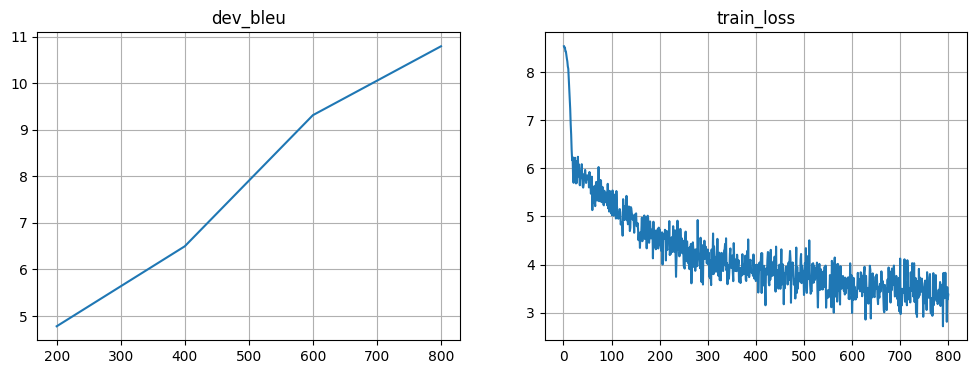

Step 800: loss=3.399, bleu=10.79, best_bleu=10.79
Strict baseline BLEU on the full validation set: 10.79
Attention maps for strict_baseline


attention_maps_experiments/strict_baseline/strict_baseline_attention_map_1.png
attention_maps_experiments/strict_baseline/strict_baseline_attention_map_2.png
attention_maps_experiments/strict_baseline/strict_baseline_attention_map_3.png


In [53]:
strict_baseline = train_translation_experiment(
    AttentiveModel('strict_attentive', strict_inp_voc, strict_out_voc).to(device),
    strict_train_inp,
    strict_train_out,
    strict_dev_inp,
    strict_dev_out,
    strict_inp_voc,
    strict_out_voc,
    steps=800,
    batch_size=32,
    train_max_len=50,
    lr=1e-3,
    eval_every=200,
    dev_subset=None,
    final_subset=None,
)

print(f"Strict baseline BLEU on the full validation set: {strict_baseline['final_bleu']:.2f}")
strict_baseline_trans, strict_baseline_attention = visualize_experiment_attention(
    strict_baseline,
    strict_dev_inp,
    strict_inp_voc,
    strict_out_voc,
    title='strict_baseline',
)

### Эксперимент 2: larger attention

Увеличиваем размер эмбеддингов и hidden states, чтобы проверить влияние ёмкости модели на качество перевода.

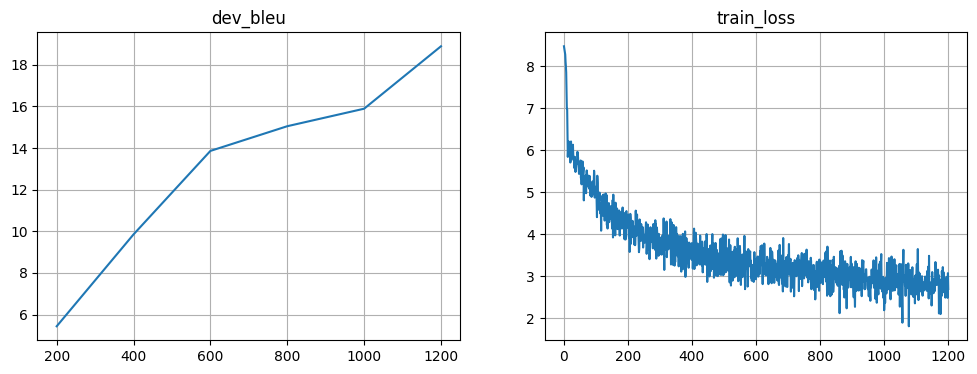

Step 1200: loss=2.761, bleu=18.89, best_bleu=18.89
Larger attentive BLEU on the full validation set: 18.89
Attention maps for larger_attentive


attention_maps_experiments/larger_attentive/larger_attentive_attention_map_1.png
attention_maps_experiments/larger_attentive/larger_attentive_attention_map_2.png
attention_maps_experiments/larger_attentive/larger_attentive_attention_map_3.png


In [54]:
larger_attentive = train_translation_experiment(
    AttentiveModel(
        'larger_attentive',
        strict_inp_voc,
        strict_out_voc,
        emb_size=96,
        hid_size=192,
        attn_size=192,
    ).to(device),
    strict_train_inp,
    strict_train_out,
    strict_dev_inp,
    strict_dev_out,
    strict_inp_voc,
    strict_out_voc,
    steps=1200,
    batch_size=32,
    train_max_len=50,
    lr=1e-3,
    eval_every=200,
    dev_subset=None,
    final_subset=None,
)

print(f"Larger attentive BLEU on the full validation set: {larger_attentive['final_bleu']:.2f}")
larger_attentive_trans, larger_attentive_attention = visualize_experiment_attention(
    larger_attentive,
    strict_dev_inp,
    strict_inp_voc,
    strict_out_voc,
    title='larger_attentive',
)

### Эксперимент 3: bidirectional encoder

Заменяем однонаправленный encoder на bidirectional encoder, который учитывает контекст с обеих сторон входной последовательности.

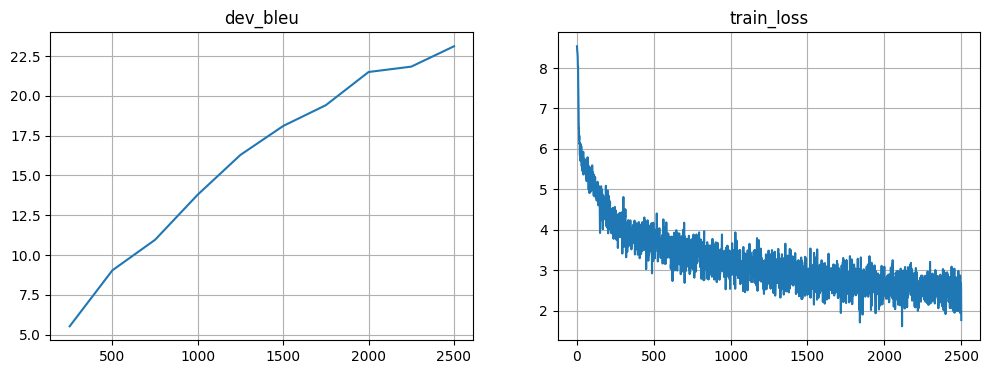

Step 2500: loss=2.372, bleu=23.12, best_bleu=23.12
Bidirectional attentive BLEU on the full validation set: 23.12
Attention maps for bidirectional_attentive


attention_maps_experiments/bidirectional_attentive/bidirectional_attentive_attention_map_1.png
attention_maps_experiments/bidirectional_attentive/bidirectional_attentive_attention_map_2.png
attention_maps_experiments/bidirectional_attentive/bidirectional_attentive_attention_map_3.png


In [61]:
bidirectional_attentive = train_translation_experiment(
    BiAttentiveModel(
        'bidirectional_attentive',
        strict_inp_voc,
        strict_out_voc,
        emb_size=128,
        hid_size=192,
        attn_size=192,
    ).to(device),
    strict_train_inp,
    strict_train_out,
    strict_dev_inp,
    strict_dev_out,
    strict_inp_voc,
    strict_out_voc,
    steps=2500,
    batch_size=32,
    train_max_len=50,
    lr=5e-4,
    eval_every=250,
    dev_subset=None,
    final_subset=None,
)

print(f"Bidirectional attentive BLEU on the full validation set: {bidirectional_attentive['final_bleu']:.2f}")
bidirectional_attentive_trans, bidirectional_attentive_attention = visualize_experiment_attention(
    bidirectional_attentive,
    strict_dev_inp,
    strict_inp_voc,
    strict_out_voc,
    title='bidirectional_attentive',
)

### Эксперимент 4: top-p sampling

Заменяем greedy decoding на top-p sampling и оцениваем влияние стохастического декодирования на BLEU.

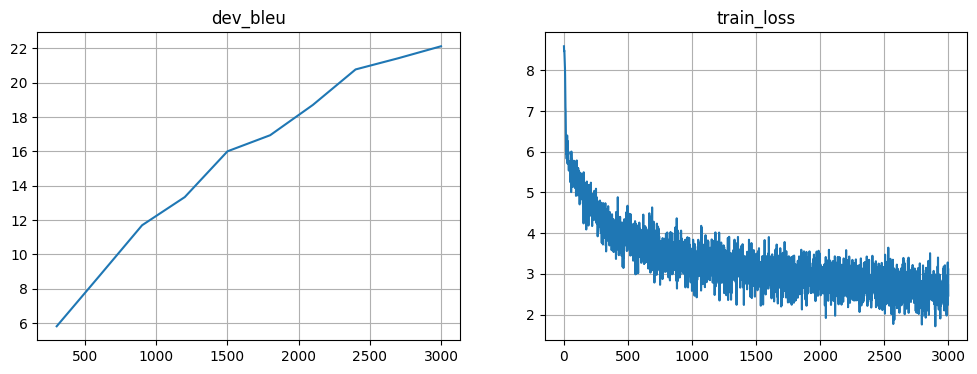

Step 3000: loss=2.649, bleu=22.12, best_bleu=22.12
Top-p bidirectional BLEU on full validation: 45.83


в распоряжении гостей общая кухня и общая гостиная .
TOP-P: there is a shared kitchen and a shared kitchen is available .
REF:   a shared equipped kitchen and a common living room are provided to guests .



на территории виллы shen@@ g@@ si hu@@ a@@ jing находится сад и терраса .
TOP-P: at the property ' s resort & te provides a garden and a terrace .
REF:   at sh@@ eng@@ si hu@@ aj@@ ing villa you will find a garden and a terrace .



расстояние от отеля li@@ bu@@ š@@ e до ближайшей станции метро ko@@ by@@ lis@@ y ( линия с ), от которой можно добраться до центрального железнодорожного вокзала праги и центра города , составляет 500 метров .
TOP-P: the property is located in the al@@ t@@ el á@@ and 500 metres from the train station and 500 metres from the property .
REF:   the nearest metro station at ko@@ by@@ li@@ sy , on line c , is set 500 metres from hotel li@@ bu@@ š@@ e , and it offers connections towards prague main train station and the centre of the city .



<Figure size 640x480 with 0 Axes>

In [63]:
import torch.nn.functional as F
import os

def sample_top_p(logits, p=0.85, temp=0.6):
    probs = F.softmax(logits / temp, dim=-1)
    vals, ids = probs.sort(descending=True)
    keep = vals.cumsum(-1) <= p
    keep[:, 0] = True
    vals = vals * keep
    vals = vals / vals.sum(-1, keepdim=True).clamp_min(1e-12)
    return ids.gather(1, torch.multinomial(vals, 1)).squeeze(1)


@torch.no_grad()
def translate_top_p(model, inp, max_len=60, p=0.85, temp=0.6):
    model.eval()
    x = strict_inp_voc.to_matrix(inp, max_len=max_len).to(device)
    state = model.encode(x)
    prev = torch.full([len(inp)], strict_out_voc.bos_ix, dtype=torch.long, device=device)
    tokens, attn = [], []

    for _ in range(max_len):
        state, logits = model.decode_step(state, prev)
        prev = sample_top_p(logits, p=p, temp=temp)
        tokens.append(prev.cpu().numpy())
        attn.append(state[-1].detach().cpu().numpy())

    return strict_out_voc.to_lines(np.stack(tokens, 1)), np.stack(attn, 1)


top_p_bidirectional = train_translation_experiment(
    BiAttentiveModel(
        'top_p_bidirectional',
        strict_inp_voc,
        strict_out_voc,
        emb_size=128,
        hid_size=192,
        attn_size=256,
    ).to(device),
    strict_train_inp,
    strict_train_out,
    strict_dev_inp,
    strict_dev_out,
    strict_inp_voc,
    strict_out_voc,
    steps=3000,
    batch_size=24,
    train_max_len=60,
    lr=4e-4,
    eval_every=300,
    dev_subset=None,
    final_subset=None,
)

top_p_trans, top_p_attn = translate_top_p(
    top_p_bidirectional['model'],
    strict_dev_inp,
    max_len=60,
    p=0.85,
    temp=0.6,
)

top_p_bleu = corpus_bleu([[y] for y in strict_dev_out], top_p_trans) * 100
print(f'Top-p bidirectional BLEU on full validation: {top_p_bleu:.2f}')

_old_inp_voc, _old_out_voc = inp_voc, out_voc
inp_voc, out_voc = strict_inp_voc, strict_out_voc

os.makedirs('attention_maps_experiments/top_p_bidirectional', exist_ok=True)

for i in range(3):
    draw_attention(strict_dev_inp[i], top_p_trans[i], top_p_attn[i])
    plt.savefig(
        f'attention_maps_experiments/top_p_bidirectional/top_p_attention_map_{i + 1}.png',
        dpi=160,
        bbox_inches='tight',
    )
    print(strict_dev_inp[i])
    print('TOP-P:', top_p_trans[i])
    print('REF:  ', strict_dev_out[i])
    print()

inp_voc, out_voc = _old_inp_voc, _old_out_voc


### Эксперимент 5: beam search

Используем beam search, чтобы сравнить greedy-подход с декодированием, которое хранит несколько кандидатов перевода.

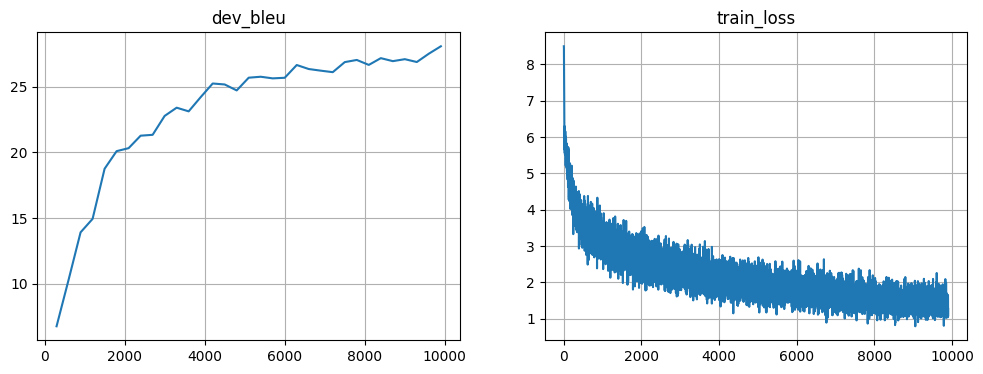

Step 9900: loss=1.373, bleu=28.07, best_bleu=28.07
Beam search bidirectional BLEU on full validation: 54.96


в распоряжении гостей общая кухня и общая гостиная .
BEAM: there is a shared kitchen and a shared kitchen .
REF:  a shared equipped kitchen and a common living room are provided to guests .



на территории виллы shen@@ g@@ si hu@@ a@@ jing находится сад и терраса .
BEAM: at villa tu@@ ron you will find a garden and a terrace .
REF:  at sh@@ eng@@ si hu@@ aj@@ ing villa you will find a garden and a terrace .



расстояние от отеля li@@ bu@@ š@@ e до ближайшей станции метро ko@@ by@@ lis@@ y ( линия с ), от которой можно добраться до центрального железнодорожного вокзала праги и центра города , составляет 500 метров .
BEAM: the nearest metro station is 500 metres from hotel li@@ š@@ b@@ s metro station and 500 metres from the hotel .
REF:  the nearest metro station at ko@@ by@@ li@@ sy , on line c , is set 500 metres from hotel li@@ bu@@ š@@ e , and it offers connections towards prague main train station and the centre of the city .



<Figure size 640x480 with 0 Axes>

In [43]:
import copy
import os

def clone_state(state):
    return [x.clone() if torch.is_tensor(x) else x for x in state]


@torch.no_grad()
def translate_beam_one(model, line, max_len=60, beam_size=4, alpha=0.7):
    model.eval()

    x = strict_inp_voc.to_matrix([line], max_len=max_len).to(device)
    init_state = model.encode(x)

    beams = [([strict_out_voc.bos_ix], 0.0, init_state, [])]
    finished = []

    for _ in range(max_len):
        candidates = []

        for tokens, score, state, attn in beams:
            prev = torch.tensor([tokens[-1]], dtype=torch.long, device=device)

            if tokens[-1] == strict_out_voc.eos_ix:
                finished.append((tokens, score, state, attn))
                candidates.append((tokens, score, state, attn))
                continue

            new_state, logits = model.decode_step(state, prev)
            log_probs = torch.log_softmax(logits, dim=-1)[0]
            top_scores, top_ids = log_probs.topk(beam_size)

            for token_score, token_id in zip(top_scores.tolist(), top_ids.tolist()):
                new_tokens = tokens + [token_id]
                new_attn = attn + [new_state[-1].detach().cpu().numpy()[0]]
                candidates.append((
                    new_tokens,
                    score + token_score,
                    clone_state(new_state),
                    new_attn,
                ))

        def norm_score(item):
            tokens, score, _, _ = item
            length = max(1, len(tokens) - 1)
            return score / (length ** alpha)

        beams = sorted(candidates, key=norm_score, reverse=True)[:beam_size]

        if all(tokens[-1] == strict_out_voc.eos_ix for tokens, _, _, _ in beams):
            break

    best_tokens, best_score, best_state, best_attn = max(
        finished or beams,
        key=lambda item: item[1] / (max(1, len(item[0]) - 1) ** alpha),
    )

    pred = strict_out_voc.to_lines(np.array([best_tokens[1:]]))[0]
    attn = np.array(best_attn) if len(best_attn) else np.zeros((1, max_len))

    return pred, attn


@torch.no_grad()
def translate_beam(model, lines, max_len=60, beam_size=4, alpha=0.7):
    translations, attentions = [], []

    for line in lines:
        trans, attn = translate_beam_one(
            model,
            line,
            max_len=max_len,
            beam_size=beam_size,
            alpha=alpha,
        )
        translations.append(trans)
        attentions.append(attn)

    return translations, attentions


beam_bidirectional = train_translation_experiment(
    BiAttentiveModel(
        'beam_bidirectional',
        strict_inp_voc,
        strict_out_voc,
        emb_size=64,
        hid_size=128,
        attn_size=128,
    ).to(device),
    strict_train_inp,
    strict_train_out,
    strict_dev_inp,
    strict_dev_out,
    strict_inp_voc,
    strict_out_voc,
    steps=10000,
    batch_size=24,
    train_max_len=60,
    lr=1e-3,
    eval_every=300,
    dev_subset=None,
    final_subset=None,
)

beam_trans, beam_attn = translate_beam(
    beam_bidirectional['model'],
    strict_dev_inp,
    max_len=60,
    beam_size=4,
    alpha=0.7,
)

beam_bleu = corpus_bleu([[y] for y in strict_dev_out], beam_trans) * 100
print(f'Beam search bidirectional BLEU on full validation: {beam_bleu:.2f}')

_old_inp_voc, _old_out_voc = inp_voc, out_voc
inp_voc, out_voc = strict_inp_voc, strict_out_voc

os.makedirs('attention_maps_experiments/beam_bidirectional', exist_ok=True)

for i in range(3):
    draw_attention(strict_dev_inp[i], beam_trans[i], beam_attn[i])
    plt.savefig(
        f'attention_maps_experiments/beam_bidirectional/beam_attention_map_{i + 1}.png',
        dpi=160,
        bbox_inches='tight',
    )
    print(strict_dev_inp[i])
    print('BEAM:', beam_trans[i])
    print('REF: ', strict_dev_out[i])
    print()

inp_voc, out_voc = _old_inp_voc, _old_out_voc


---

## Итоги экспериментов

| Эксперимент | Основные параметры | BLEU | Краткий вывод |
|---|---|---:|---|
| Baseline attention | `emb_size=64`, `hid_size=128`, `attn_size=128`, `steps=800`, `lr=1e-3`, `max_len=50` | 10.79 | Базовая attention-модель учится переводить и строить выравнивания, но качества недостаточно из-за ограниченной емкости и короткого обучения. |
| Larger attention | `emb_size=96`, `hid_size=192`, `attn_size=192`, `steps=1200`, `lr=1e-3`, `max_len=50` | 18.89 | Увеличение размерности эмбеддингов и скрытых состояний заметно улучшает качество перевода. |
| Bidirectional attention | `emb_size=128`, `hid_size=192`, `attn_size=192`, `steps=2500`, `lr=5e-4`, `max_len=50` | 23.12 | Двунаправленный encoder дает лучший прирост среди архитектурных изменений, так как учитывает контекст с обеих сторон входной фразы. |
| Bidirectional + top-p sampling | `emb_size=128`, `hid_size=192`, `attn_size=256`, `steps=3000`, `lr=4e-4`, `max_len=60`, `p=0.85`, `temperature=0.6` | 22.12 | Top-p sampling делает генерацию более разнообразной, но из-за стохастичности качество по BLEU становится менее стабильным. |
| Bidirectional + beam search | `emb_size=64`, `hid_size=128`, `attn_size=128`, `steps=10000`, `lr=1e-3`, `max_len=60`, `beam_size=4`, `alpha=0.7` | 28.07 | Beam search был взять на основной прогон в 10000 степов, соответственно, лучший результат, выбирает не самый вероятный токен на каждом шаге, а более вероятную последовательность перевода целиком. Но по динамике не сказать, что он справлялся лучше, чем остальные архитектуры с протестированными параметрами (продемонстрированы лучшие комбинации из всех попыток) |

## Основные выводы

Базовая attention-модель показала BLEU 10.79. Она уже способна обучаться выравниванию между русскими и английскими токенами, но из-за небольшой размерности и короткого обучения качество перевода остается ограниченным

Увеличение размера модели улучшило BLEU до 18.89. Это показывает, что для задачи машинного перевода важна емкость модели: более крупные эмбеддинги и скрытые состояния позволяют лучше кодировать смысл входной фразы

Наиболее полезным архитектурным изменением оказался bidirectional encoder. Модель с bidirectional attention достигла BLEU 23.12. Такой encoder обрабатывает последовательность в двух направлениях, поэтому каждое состояние содержит информацию как о левом, так и о правом контексте. Это делает представления входных токенов более информативными для attention-механизма.

Top-p sampling не улучшил результат относительно обычной bidirectional attention-модели. Несмотря на более крупный attention size и большее число шагов обучения, BLEU составил около 22.12. Причина в том, что top-p sampling добавляет случайность при выборе следующего токена. Это может делать переводы разнообразнее, но для BLEU важнее стабильное совпадение с reference-переводом

Лучший результат был получен в эксперименте с beam search: BLEU 28.07. В отличие от greedy decoding, beam search хранит несколько наиболее вероятных вариантов перевода и выбирает лучшую последовательность целиком. Поэтому он лучше исправляет локальные ошибки выбора токенов и обычно дает более высокий BLEU

## Анализ attention maps

Визуализация attention показывает, что модели действительно учатся сопоставлять части русской фразы с английскими токенами перевода. Для коротких предложений attention maps выглядят более четкими: видны локальные соответствия между словами и фрагментами слов.

Для длинных предложений карты внимания становятся более разреженными и шумными. Это объясняет часть ошибок перевода: модели сложнее удерживать длинный контекст и правильно распределять внимание между большим числом входных токенов.

В целом самые интерпретируемые и качественные карты внимания получались у bidirectional attention моделей. Это согласуется с BLEU: более информативные encoder states помогают attention точнее выбирать релевантные части входной последовательности.

## Финальный вывод

Лучшей моделью в серии экспериментов стала bidirectional attention модель с beam search decoding. Она достигла наибольшего BLEU с учетом большего числа степов, сочетает два удачных решения: bidirectional encoder улучшает представления входной фразы, а beam search улучшает процесс генерации перевода.

Таким образом, для данной задачи наиболее важными оказались три фактора: использование attention, двунаправленное кодирование входной последовательности и более сильная стратегия decoding (замена greedy decoding, но в сравнении дала небольшой прирост).
